In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.neighbors import KernelDensity

from rital_nlp_project.common.utils import load_clean_data, load_pres
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents

from rital_nlp_project.presidents.models import SmoothedProbaClassifier, smooth_gauss
from rital_nlp_project.presidents.models_utils import *
from rital_nlp_project.presidents.utils import load_with_numbers

init_notebook()

In [2]:
texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean_bert.parquet")
embeds = np.load("../Dataset/embeddings/pres_camembert_large.npy") 
#df_ids = load_with_numbers("../Dataset/presidents.utf8")
#df_ids["class"] = classes_pres
classes_pres = np.where(classes_pres == -1, 1, 0)

### Train/test split

In [3]:
X_train, X_test, y_train, y_test = split_fn(embeds, classes_pres)

In [4]:
# Feature engineering
X_train_concat, X_test_concat, y_train_concat, y_test_concat = expand_train_test(X_train, X_test, y_train, y_test, n=1)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_concat, y_train_concat)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
probas = model.predict_proba(X_test_concat)

sigma = 1
probas_smooth = smooth_gauss(model.predict_proba(X_test_concat),
                             sigma=sigma)
pred = probas_smooth.argmax(axis=1)

df = pd.DataFrame(data={
    "true":y_test_concat,
    "pred":pred,
    "prob_smooth":probas_smooth[:, 1],
    "prob_raw":probas[:, 1]
})

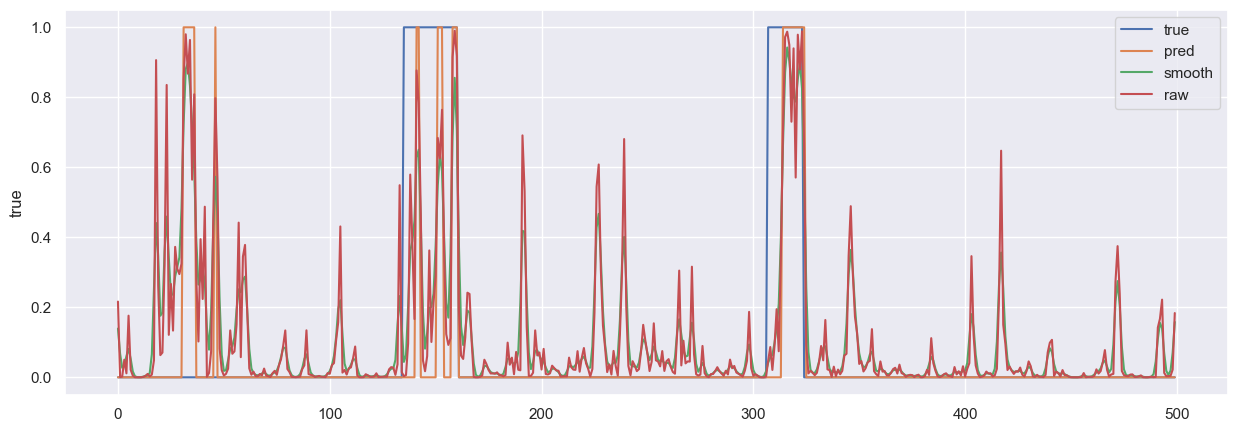

In [18]:
plt.figure(figsize=(15, 5))

mn, mx = 0, 500
sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["pred"].iloc[mn:mx], label="pred")
sns.lineplot(df["prob_smooth"].iloc[mn:mx], label="smooth")
sns.lineplot(df["prob_raw"].iloc[mn:mx], label="raw")
plt.legend() 

In [19]:
unique_class, lengths = get_seq_len(y_train)

kde_0 = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde_1 = KernelDensity(kernel='gaussian', bandwidth=1.0)
len_0 = lengths[unique_class == 0]
len_1 = lengths[unique_class == 1]

kde_0.fit(len_0.reshape(-1, 1))
kde_1.fit(len_1.reshape(-1, 1))

D_max_0 = len_0.max()
D_max_1 = len_1.max()

D_max = [D_max_0, D_max_1]
kde = [kde_0, kde_1]

log_probs = model.predict_log_proba(X_test_concat)
S = get_scores_smooth_duration(log_probs, D_max, kde)
#probas_smooth = smooth_prob_duration(probas, 0.6, S)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

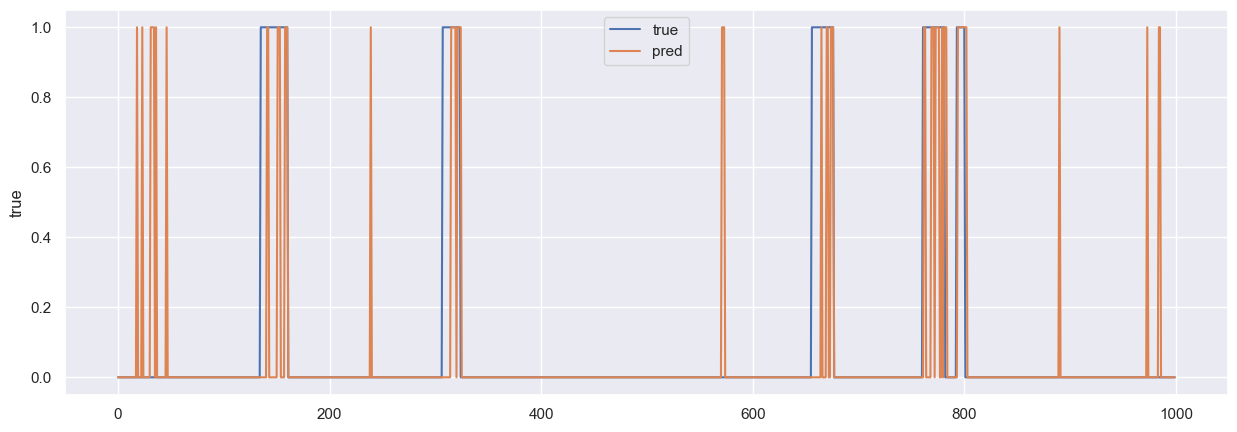

In [ ]:
alpha = 0.9
probas_smooth = smooth_prob_duration(probas, alpha, S)
pred = smooth_gauss(probas_smooth.argmax(axis=1))

df = pd.DataFrame(data={
    "true":y_test_concat,
    "pred":pred,
    "prob_smooth":probas_smooth[:, 1],
    "prob_raw":probas[:, 1]
})

plt.figure(figsize=(15, 5))

mn, mx = 0, 1000
sns.lineplot(df["true"].iloc[mn:mx], label="true")
sns.lineplot(df["pred"].iloc[mn:mx], label="pred")
#sns.lineplot(df["prob_smooth"].iloc[mn:mx], label="smooth")
#sns.lineplot(df["prob_raw"].iloc[mn:mx], label="raw")
plt.legend() 

In [ ]:
pred = np.argmax(probas_smooth, axis=1)
print(accuracy_score(y_test_concat, pred))
print(precision_score(y_test_concat, pred))
print(recall_score(y_test_concat, pred))
print(f1_score(y_test_concat, pred, average="macro"))
print(roc_auc_score(y_test_concat, probas_smooth[:, 1]))

0.9065412420520861
0.5251396648044693
0.8082545141874462
0.7915074180046002
0.9531977692358077


#### True test eval

In [39]:
# Load true test dataset
df_test = pd.read_parquet("../Dataset/embeddings/presidents_test_metadata_camembert-large.parquet")
X_test = np.stack(df_test["embedding"].to_numpy())
X_test

array([[ 7.31243864e-02,  1.51087940e-01,  3.43201667e-01, ...,
         1.49358600e-01, -3.60857956e-02, -5.71150854e-02],
       [ 1.13912344e-01,  7.95032755e-02,  1.06489763e-01, ...,
         2.30763331e-01, -1.11681044e-01, -2.23053336e-01],
       [-3.99891675e-01,  2.17171937e-01,  2.26480827e-01, ...,
         1.23760276e-01,  1.25295907e-01, -4.21054065e-02],
       ...,
       [-3.74694653e-02,  1.42264664e-01,  2.46501222e-01, ...,
         1.26727909e-01, -9.98448860e-03, -3.48990798e-01],
       [-3.23684990e-01,  1.78836226e-01,  2.63020515e-01, ...,
         1.74744928e-04,  1.11757651e-01, -8.05989653e-02],
       [ 1.03843741e-01,  1.86888754e-01,  2.88044363e-01, ...,
         3.62314135e-01, -6.97851852e-02, -1.38824865e-01]],
      shape=(27162, 1024))

In [40]:
X_train, y_train = embeds, classes_pres
X_train_concat, X_test_concat, y_train_concat, y_test_concat = expand_train_test(X_train, X_test, y_train, y_test, n=1)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_concat, y_train_concat)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
probas = model.predict_proba(X_test_concat)

sigma = 4
probas_smooth = smooth_gauss(model.predict_proba(X_test_concat),
                             sigma=sigma)
pred = probas_smooth.argmax(axis=1)

df = pd.DataFrame(data={
    # "true":y_test_concat,
    "pred":pred,
    "prob_smooth":probas_smooth[:, 1],
    "prob_raw":probas[:, 1]
})

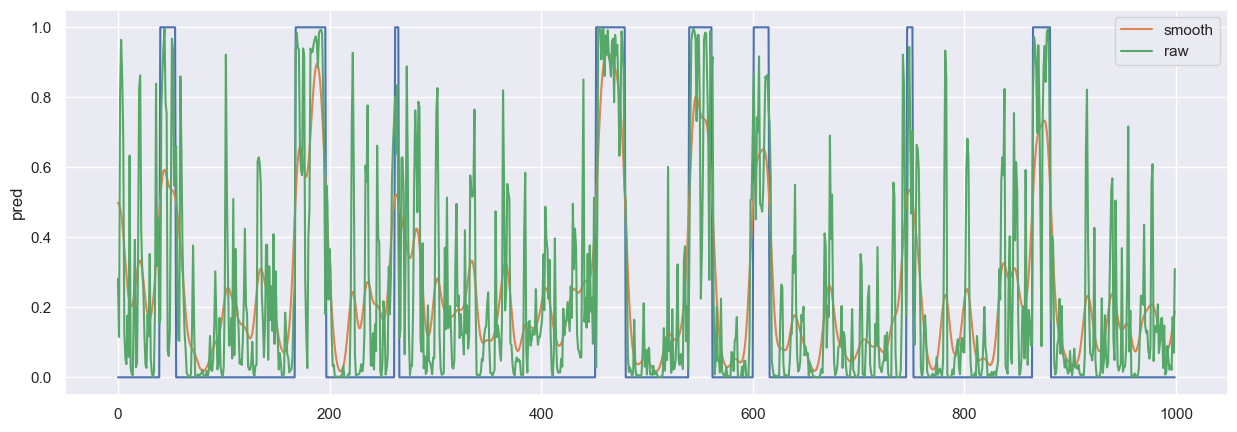

In [48]:
plt.figure(figsize=(15, 5))

mn, mx = 0, 1000
sns.lineplot(df["pred"].iloc[mn:mx])
sns.lineplot(df["prob_smooth"].iloc[mn:mx], label="smooth")
sns.lineplot(df["prob_raw"].iloc[mn:mx], label="raw")
plt.legend() 

In [49]:
probs_df = pd.DataFrame(data={"prob":np.pad(probas_smooth[:, 1], 1, mode="edge")})
probs_df.to_csv("../Dataset/submissions/submission-pres-2.csv", header=None, index=False)